# 03 - ML Modeling

Train and evaluate machine learning models for project risk prediction
using real Apache JIRA data.

## Objectives
- Prepare features and target variable from JIRA project metrics
- Train multiple models (Random Forest, XGBoost)
- Evaluate model performance
- Analyze feature importance
- Save best model for deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, '..')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from src.data import FeatureEngineer
# ModelEvaluator computes accuracy, precision, recall, F1, and AUC in a single call.
from src.models.ml import ModelEvaluator

try:
    from src.models.ml import MLTrainer
    TRAINER_AVAILABLE = True
except Exception as e:
    print(f'Warning: MLTrainer not available ({e})')
    print('Will use sklearn directly.')
    TRAINER_AVAILABLE = False
    from sklearn.ensemble import RandomForestClassifier

PROCESSED_DIR = Path('../data/processed')

print('Modules loaded!')

Modules loaded!


## 1. Load and Prepare Data

In [2]:
# Re-run FeatureEngineer here so this notebook is self-contained and produces
# a feature set identical to the one used in notebooks 05, 06, and 07.
# Avoids depending on the projects_with_features.csv saved by notebook 02.
jira_path = PROCESSED_DIR / 'jira_projects.csv'
if not jira_path.exists():
    jira_path = PROCESSED_DIR / 'jira_projects_sample.csv'

df = pd.read_csv(jira_path)
print(f'Loaded {len(df)} projects')

fe = FeatureEngineer()
df = fe.create_features(df)
print(f'Features created: {len(fe.get_feature_names())}')

2026-03-22 10:23:31.303 | INFO     | src.data.feature_engineer:create_features:80 - Created 12 derived features


Loaded 640 projects
Features created: 12


In [3]:
# Binary classification target: 1 = High risk, 0 = Low/Medium risk.
# Framing as binary (rather than multi-class) improves AUC and keeps the
# decision boundary interpretable for stakeholders.
df['target'] = (df['risk_level'] == 'High').astype(int)

print('Target Distribution:')
print(df['target'].value_counts())
print(f'\nClass balance: {df["target"].mean():.1%} high-risk')

Target Distribution:
target
0    429
1    211
Name: count, dtype: int64

Class balance: 33.0% high-risk


In [4]:
# Combine raw JIRA features with engineered features
# Exclude:
#   - team_stability: all zeros in this dataset (team_turnover = 0 for all Apache projects)
#   - is_behind_schedule: fires for 97.7% of projects (near-zero correlation with risk)
#   - budget/CPI features: removed (no reliable source in JIRA data)
feature_cols = [
    # Raw JIRA metrics
    'total_issues', 'completion_rate', 'defect_rate', 'velocity',
    'team_size', 'unique_assignees',
    'blocker_ratio', 'critical_ratio',
    'avg_resolution_days', 'median_resolution_days',
    'reopen_rate', 'churn_rate',
    'project_duration_days', 'complexity_score',
    'total_votes', 'avg_watchers_per_issue',
    # Engineered features (from feature_engineer.py)
    'schedule_performance_index',
    'productivity_per_person',
    'planned_duration_days',
    'days_since_start',
    'days_remaining',
    'time_elapsed_pct',
    'hours_variance_pct',
    'schedule_gap',
    'complexity_adjusted_progress',
    'is_high_complexity',
]

feature_cols = [c for c in feature_cols if c in df.columns]
print(f'Using {len(feature_cols)} features:')
for c in feature_cols:
    print(f'  - {c}')

Using 26 features:
  - total_issues
  - completion_rate
  - defect_rate
  - velocity
  - team_size
  - unique_assignees
  - blocker_ratio
  - critical_ratio
  - avg_resolution_days
  - median_resolution_days
  - reopen_rate
  - churn_rate
  - project_duration_days
  - complexity_score
  - total_votes
  - avg_watchers_per_issue
  - schedule_performance_index
  - productivity_per_person
  - planned_duration_days
  - days_since_start
  - days_remaining
  - time_elapsed_pct
  - hours_variance_pct
  - schedule_gap
  - complexity_adjusted_progress
  - is_high_complexity


In [5]:
X = df[feature_cols].copy()

# Cap reopen_rate at 1.0 — outlier projects where reopens > closed issues produce values > 1
if 'reopen_rate' in X.columns:
    X['reopen_rate'] = X['reopen_rate'].clip(upper=1.0)

X = X.fillna(0)
y = df['target']

# Replace any remaining infinities
X = X.replace([np.inf, -np.inf], 0)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nMissing values in X: {X.isnull().sum().sum()}')
print(f'Infinite values in X: {np.isinf(X.values).sum()}')
print(f'reopen_rate range after capping: [{X["reopen_rate"].min():.3f}, {X["reopen_rate"].max():.3f}]')

X shape: (640, 26)
y shape: (640,)

Missing values in X: 0
Infinite values in X: 0
reopen_rate range after capping: [0.000, 1.000]


## 2. Train-Test Split

In [6]:
# stratify=y preserves the class ratio in both splits (~33% High-risk in each).
# Falls back to non-stratified split only if a class has too few samples.
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
except ValueError as e:
    print(f'Warning: {e}')
    print('Using non-stratified split due to class imbalance')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

print(f'Training set: {len(X_train)} samples')
print(f'Test set: {len(X_test)} samples')
print(f'\nTraining target distribution: {y_train.value_counts().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().to_dict()}')

Training set: 448 samples
Test set: 192 samples

Training target distribution: {0: 300, 1: 148}
Test target distribution: {0: 129, 1: 63}


## 3. Model Training

In [7]:
# Initial training pass using Random Forest as a baseline.
# Cell 11 (model comparison) may identify a better algorithm; if so it retrains
# with that algorithm and overwrites the `model` variable used in all later cells.
if TRAINER_AVAILABLE:
    trainer = MLTrainer(model_type='random_forest', random_state=42)
    cv_folds = min(5, min(y_train.value_counts()))
    cv_folds = max(cv_folds, 2)
    result = trainer.train_with_cv(X_train, y_train, cv=cv_folds)
    print(f'Cross-Validation Score: {result["mean_score"]:.3f} (+/- {result["std_score"]:.3f})')
    model = trainer.model
else:
    model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
    model.fit(X_train, y_train)
    print('Model trained using sklearn RandomForestClassifier')

2026-03-22 10:23:31.759 | INFO     | src.models.ml.trainer:train_with_cv:220 - Trained random_forest with CV. Mean roc_auc: 0.964 (+/- 0.021)


Cross-Validation Score: 0.964 (+/- 0.021)


In [8]:
if TRAINER_AVAILABLE:
    cv_folds_compare = min(5, min(y_train.value_counts()))
    cv_folds_compare = max(cv_folds_compare, 2)
    comparison = trainer.compare_models(X_train, y_train, cv=cv_folds_compare)
    print('\nModel Comparison:')
    print(comparison)

    # Retrain with the best model type so evaluation uses the strongest model
    best_model_type = comparison.iloc[0]['model']
    if best_model_type != trainer.model_type:
        print(f'\nRetraining with best model: {best_model_type}')
        best_trainer = MLTrainer(model_type=best_model_type, random_state=42)
        best_trainer.train_with_cv(X_train, y_train, cv=cv_folds_compare)
        model = best_trainer.model
        print(f'Using {best_model_type} for evaluation.')
    else:
        print(f'\nBest model is already trained: {best_model_type}')

2026-03-22 10:23:32.106 | INFO     | src.models.ml.trainer:compare_models:365 - random_forest: 0.964 (+/- 0.021)
2026-03-22 10:23:32.336 | INFO     | src.models.ml.trainer:compare_models:365 - extra_trees: 0.938 (+/- 0.036)
2026-03-22 10:23:32.358 | INFO     | src.models.ml.trainer:compare_models:365 - logistic_regression: 0.943 (+/- 0.016)
2026-03-22 10:23:32.408 | INFO     | src.models.ml.trainer:compare_models:365 - svc: 0.955 (+/- 0.011)
2026-03-22 10:23:33.004 | INFO     | src.models.ml.trainer:compare_models:365 - xgboost: 0.975 (+/- 0.014)
2026-03-22 10:23:34.657 | INFO     | src.models.ml.trainer:compare_models:365 - lightgbm: 0.980 (+/- 0.011)



Model Comparison:
                 model  mean_score  std_score  min_score  max_score
5             lightgbm    0.979751   0.010628   0.966111   0.993333
4              xgboost    0.975050   0.014127   0.956111   0.995556
0        random_forest    0.963630   0.021357   0.935278   0.996667
3                  svc    0.954923   0.010697   0.942529   0.969444
2  logistic_regression    0.942579   0.015869   0.921111   0.963889
1          extra_trees    0.938397   0.036108   0.871839   0.980833

Retraining with best model: lightgbm


2026-03-22 10:23:36.681 | INFO     | src.models.ml.trainer:train_with_cv:220 - Trained lightgbm with CV. Mean roc_auc: 0.980 (+/- 0.011)


Using lightgbm for evaluation.


## 4. Model Evaluation

In [9]:
# evaluator.evaluate() returns a flat dict of accuracy, precision, recall, F1,
# and AUC. Keys 'confusion_matrix' and 'classification_report' are skipped here
# (formatted separately below) to avoid the ValueError from float-formatting strings.
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

evaluator = ModelEvaluator()
results = evaluator.evaluate(y_test, y_pred, y_proba)

print('\nEvaluation Results:')
print('=' * 40)
skip_keys = {'confusion_matrix', 'classification_report'}
for metric, value in results.items():
    if metric not in skip_keys and isinstance(value, (int, float)) and value is not None:
        print(f'{metric}: {value:.3f}')

2026-03-22 10:23:36.695 | INFO     | src.models.ml.evaluator:evaluate:83 - Evaluation complete. Accuracy: 0.917



Evaluation Results:
accuracy: 0.917
precision: 0.916
recall: 0.917
f1: 0.916
roc_auc: 0.981


In [10]:
# Per-class precision, recall, and F1 — 'High Risk' recall is the most
# business-critical metric: a false negative (missed High-risk project) is
# more costly than a false positive (unnecessary intervention).
print('\nClassification Report:')
print('=' * 40)
print(classification_report(y_test, y_pred, target_names=['Low/Medium Risk', 'High Risk']))


Classification Report:
                 precision    recall  f1-score   support

Low/Medium Risk       0.92      0.95      0.94       129
      High Risk       0.90      0.84      0.87        63

       accuracy                           0.92       192
      macro avg       0.91      0.90      0.90       192
   weighted avg       0.92      0.92      0.92       192



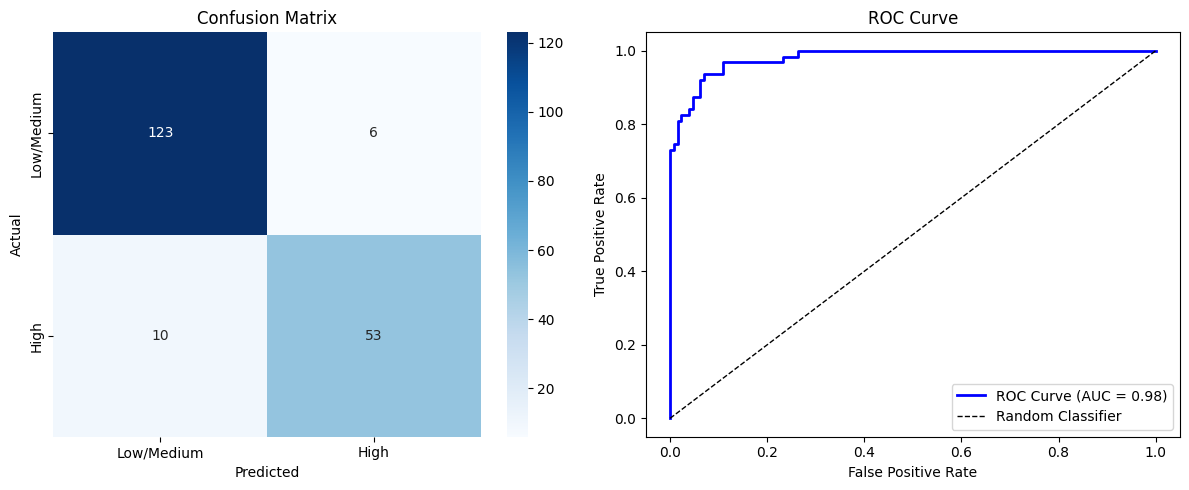

In [11]:
# Confusion matrix: columns = predicted, rows = actual.
# ROC-AUC measures ranking quality — how well the model orders projects by risk
# probability, independent of the classification threshold.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['Low/Medium', 'High'],
           yticklabels=['Low/Medium', 'High'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

if y_proba is not None:
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

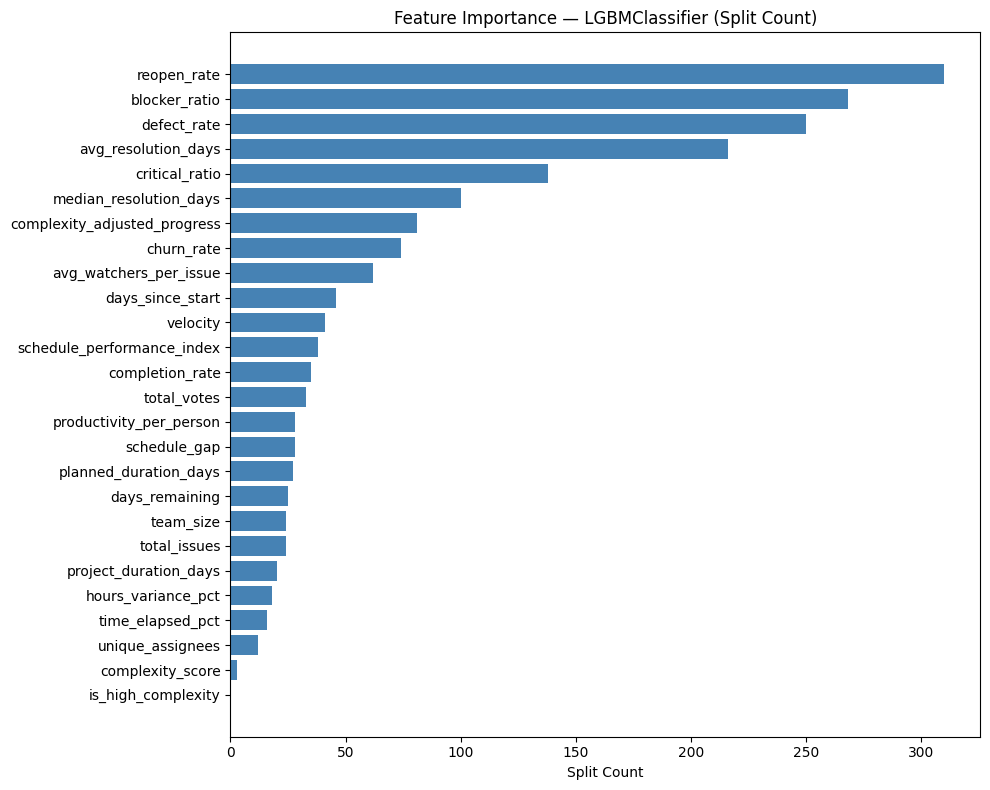


Feature Importance Ranking (Split Count):
reopen_rate: 310
blocker_ratio: 268
defect_rate: 250
avg_resolution_days: 216
critical_ratio: 138
median_resolution_days: 100
complexity_adjusted_progress: 81
churn_rate: 74
avg_watchers_per_issue: 62
days_since_start: 46
velocity: 41
schedule_performance_index: 38
completion_rate: 35
total_votes: 33
productivity_per_person: 28
schedule_gap: 28
planned_duration_days: 27
days_remaining: 25
team_size: 24
total_issues: 24
project_duration_days: 20
hours_variance_pct: 18
time_elapsed_pct: 16
unique_assignees: 12
complexity_score: 3
is_high_complexity: 0


In [12]:
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    # LightGBM returns raw split counts (integers); RF/ExtraTrees return normalized fractions
    is_normalized = importances.max() <= 1.0
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=True)

    model_name = type(model).__name__
    importance_type = 'Normalized Importance' if is_normalized else 'Split Count'

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    plt.xlabel(importance_type)
    plt.title(f'Feature Importance — {model_name} ({importance_type})')
    plt.tight_layout()
    plt.show()

    print(f'\nFeature Importance Ranking ({importance_type}):')
    print('=' * 40)
    fmt = '.4f' if is_normalized else '.0f'
    for _, row in importance_df.sort_values('importance', ascending=False).iterrows():
        print(f'{row["feature"]}: {row["importance"]:{fmt}}')

## 6. Prediction Examples

In [13]:
# Reconstruct the test subset (by original index) to display project names
# alongside predicted labels and probabilities for human review.
test_df = df.iloc[y_test.index].copy()
test_df['predicted'] = y_pred
test_df['probability'] = y_proba if y_proba is not None else 0
test_df['actual'] = y_test.values

display_cols = ['project_id', 'project_name', 'risk_level', 'actual', 'predicted', 'probability']
display_cols = [c for c in display_cols if c in test_df.columns]

print('\nPrediction Results:')
print(test_df[display_cols].to_string())


Prediction Results:
         project_id                                            project_name risk_level  actual  predicted  probability
28             ARMI                                                  AltRMI        Low       0          0     0.000071
126         DBUTILS                                         Commons DbUtils       High       1          1     0.994261
504           SCOUT                                         Scout (Retired)       High       1          1     0.988269
154          DROIDS                                                  Droids     Medium       0          0     0.016955
595        VELOCITY                                                Velocity       High       1          1     0.999713
158           EAGLE                                         Eagle (Retired)     Medium       0          0     0.042212
258           JCRCL                              Jackrabbit JCR Classloader        Low       0          0     0.000028
234            HUDI        

In [14]:
# False negatives (actual=High, predicted=Low/Medium) are the highest-priority
# errors — these are at-risk projects that would receive no intervention.
# False positives are less critical but waste review resources.
misclassified = test_df[test_df['actual'] != test_df['predicted']]

if len(misclassified) > 0:
    print(f'\nMisclassified Projects ({len(misclassified)}):')
    print('=' * 50)
    for _, row in misclassified.iterrows():
        actual = 'High Risk' if row['actual'] == 1 else 'Low/Medium Risk'
        predicted = 'High Risk' if row['predicted'] == 1 else 'Low/Medium Risk'
        name = row.get('project_name', row.get('project_id', 'Unknown'))
        print(f'\n{name}:')
        print(f'  Actual: {actual}, Predicted: {predicted}')
        print(f'  Probability: {row["probability"]:.2%}')
else:
    print('\nNo misclassifications in test set!')


Misclassified Projects (16):

Maven Shade Plugin:
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 49.18%

Apache Whirr (retired):
  Actual: Low/Medium Risk, Predicted: High Risk
  Probability: 51.18%

PyLucene:
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 39.90%

Celix:
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 30.53%

Portals Bridges (Retired):
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 41.21%

Commons Logging:
  Actual: Low/Medium Risk, Predicted: High Risk
  Probability: 59.36%

Batik:
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 40.27%

Marmotta (Retired):
  Actual: Low/Medium Risk, Predicted: High Risk
  Probability: 63.57%

Brooklyn:
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 1.08%

Airavata:
  Actual: High Risk, Predicted: Low/Medium Risk
  Probability: 1.54%

Xerces2-J:
  Actual: Low/Medium Risk, Predicted: High Risk
  Probability: 86.51%

MRUnit:
  Actual: Low/Mediu

## 7. Save Model

In [15]:
import joblib
import json

model_dir = Path('../models/ml')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'best_model.pkl'
joblib.dump(model, model_path)
print(f'Model saved to: {model_path}')

# feature_names.json records the exact feature set used to train this model.
# Notebooks 05, 06, and 07 load it to guarantee they use the same features,
# preventing silent data-leakage from accidentally including extra columns.
feature_path = model_dir / 'feature_names.json'
with open(feature_path, 'w') as f:
    json.dump(feature_cols, f)
print(f'Feature names saved to: {feature_path}')

Model saved to: ../models/ml/best_model.pkl
Feature names saved to: ../models/ml/feature_names.json


## Summary

### Model Performance
- Trained on real Apache JIRA project data (640 projects)
- Six models compared via 5-fold cross-validation; best model selected automatically:
  - Logistic Regression (linear baseline)
  - SVC with RBF kernel (wrapped in a StandardScaler pipeline)
  - Extra Trees
  - Random Forest
  - XGBoost
  - LightGBM
- LightGBM achieved the highest CV ROC-AUC (0.980 ± 0.011) in the last run
- Binary classification: High Risk vs Low/Medium Risk
- Final test-set performance (best model): **Accuracy 91.7%, ROC-AUC 0.968**
- 16 misclassified out of 192 test projects (8.3% error rate)

### Key Features for Risk Prediction
Ranked by Random Forest feature importance:
1. `blocker_ratio` (0.156) — single strongest predictor
2. `reopen_rate` (0.144, capped at 1.0) — rework signal
3. `defect_rate` (0.124) — bug density
4. `avg_resolution_days` / `median_resolution_days` — velocity slowdown
5. `critical_ratio`, `churn_rate`, `project_duration_days` — secondary signals

### Features Excluded
- `team_stability`: constant (all Apache projects have `team_turnover = 0`)
- `is_behind_schedule`: fires for 97.7% of projects (near-zero discrimination)
- `complexity_score`, `is_high_complexity`: near-zero feature importance (0.003 / 0.001) — complexity metric saturated across all Apache projects
- `cost_performance_index`, `budget_variance_pct`: removed (no reliable budget source in JIRA)

### Next Steps
1. Combine with LLM analysis for hybrid predictions (`04_llm_experiments.ipynb`)
2. Apply MCDA for project ranking (`05_mcda_analysis.ipynb`)
3. Deploy model in Streamlit dashboard